# Comparaison ERM vs Data Augmentation
Simulation de la performance de différentes fonctions de perte (Logistic, Hinge, Squared)
sur un modèle source et des modèles cibles (hôpitaux), avec et sans augmentation de données.

## 1. Imports et configuration

In [25]:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Make sure local modules are importable
ROOT = pathlib.Path().resolve() / "Empirical-risk-minimization-asymptotics"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Import project code ---
import data_models as dm
import losses_regularizers as lr
import erm_theory as et
import data_augmentation as augm

## 2. Paramètres globaux

In [26]:
rng_train = np.random.default_rng(0)
rng_test  = np.random.default_rng(1)

n_train = 50
n_test  = 2000
p       = 30
m       = 1
sigma   = 1

# Paramètres de l'hôpital cible
theta_e = 0.1
s_e     = 0.1

# Paramètres de l'augmentation
rho  = 0.1
beta = 0.1

# Régularisation
lam = 0.1

## 3. Fonctions utilitaires

In [27]:
def generate_source_model(p, delta, sigma, gamma_pos=0.5):
    C = sigma**2 * np.eye(p)
    e1 = np.zeros(p)
    e1[0] = 1.0
    mu_pos = delta * e1
    mu_neg = -delta * e1
    x_neg = dm.GaussianModel(p=p, mu=mu_neg, C=C)
    x_pos = dm.GaussianModel(p=p, mu=mu_pos, C=C)
    return dm.MultiClassModel(
        components=[x_neg, x_pos],
        gamma=[1.0 - gamma_pos, gamma_pos],
        y_values=[-1.0, +1.0],
    )


def generate_target_model(p, delta, sigma, rotation, biais, gamma_pos=0.5):
    C = sigma**2 * np.eye(p)
    e1 = np.zeros(p)
    e1[0] = 1.0
    mu_pos = delta * e1
    mu_neg = -delta * e1
    mean_pos = (rotation @ mu_pos) + biais
    mean_neg = (rotation @ mu_neg) + biais
    x_neg = dm.GaussianModel(p=p, mu=mean_neg, C=C)
    x_pos = dm.GaussianModel(p=p, mu=mean_pos, C=C)
    return dm.MultiClassModel(
        components=[x_neg, x_pos],
        gamma=[1.0 - gamma_pos, gamma_pos],
        y_values=[-1.0, +1.0],
    )


def rotation(theta, p):
    R = np.eye(p)
    R[0, 0] =  np.cos(theta)
    R[0, 1] = -np.sin(theta)
    R[1, 0] =  np.sin(theta)
    R[1, 1] =  np.cos(theta)
    return R


def random_rotation_from_identity(n, rng, theta=1.0):
    """
    Generate a random rotation matrix at 'distance' theta from identity.
    theta=0 → Identity matrix
    theta large → Far from identity
    """
    A = rng.standard_normal((n, n))
    K = (A - A.T) / 2  # skew-symmetric part
    return expm(theta * K)


def make_transform(rho, beta, rng):
    def transform(X):
        R_eps = random_rotation_from_identity(p, rng=rng, theta=rho)
        eps = R_eps - np.eye(p)
        eta = rng.uniform(-beta, beta, size=p)
        return X @ (np.eye(p) + eps).T + eta
    return transform

## 4. Définition des modèles et de la régularisation

In [28]:
loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))

R_e = rotation(theta_e, p)
b_e = np.zeros(p)
b_e[1] = s_e

model_train = generate_source_model(sigma=sigma, p=p, delta=m)
model_test  = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)

## 5. Entraînement ERM (sans augmentation)

In [29]:
# Logistic loss
trainer1 = et.ERMTrainer(model=model_train, loss=loss1, regularizer=reg)
theta_hat1, _, _ = trainer1.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Hinge loss
trainer2 = et.ERMTrainer(model=model_train, loss=loss2, regularizer=reg)
theta_hat2, _, _ = trainer2.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Squared loss
trainer3 = et.ERMTrainer(model=model_train, loss=loss3, regularizer=reg)
theta_hat3, _, _ = trainer3.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

## 6. Évaluation ERM — source et 1 hôpital cible

In [30]:
erreur_log_source     = model_train.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test)
erreur_hinge_source   = model_train.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test)
erreur_squared_source = model_train.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test)

erreur_log     = model_test.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test)
erreur_hinge   = model_test.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test)
erreur_squared = model_test.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test)

print("=== ERM — Erreurs source ===")
print(f"  Logistic : {erreur_log_source:.4f}")
print(f"  Hinge    : {erreur_hinge_source:.4f}")
print(f"  Squared  : {erreur_squared_source:.4f}")
print("\n=== ERM — Erreurs 1 hôpital cible ===")
print(f"  Logistic : {erreur_log:.4f}")
print(f"  Hinge    : {erreur_hinge:.4f}")
print(f"  Squared  : {erreur_squared:.4f}")

=== ERM — Erreurs source ===
  Logistic : 0.2670
  Hinge    : 0.2575
  Squared  : 0.2370

=== ERM — Erreurs 1 hôpital cible ===
  Logistic : 0.2680
  Hinge    : 0.2495
  Squared  : 0.2370


## 7. Évaluation ERM — moyenne sur 100 hôpitaux

In [31]:
nb_hopit = 100
erreur_log_final = erreur_hinge_final = erreur_squared_final = 0.0
theta = theta_e
s = s_e

for i in range(nb_hopit):
    theta += 0.002
    s += 0.002
    R_e = rotation(theta, p)
    b_e = np.zeros(p)
    b_e[1] = s
    mt = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)
    erreur_log_final     += mt.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test)
    erreur_hinge_final   += mt.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test)
    erreur_squared_final += mt.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test)

print("=== ERM — Moyenne 100 hôpitaux ===")
print(f"  Logistic : {erreur_log_final/nb_hopit:.4f}")
print(f"  Hinge    : {erreur_hinge_final/nb_hopit:.4f}")
print(f"  Squared  : {erreur_squared_final/nb_hopit:.4f}")

=== ERM — Moyenne 100 hôpitaux ===
  Logistic : 0.2751
  Hinge    : 0.2641
  Squared  : 0.2286


## 8. Entraînement avec augmentation de données

In [32]:
transform = make_transform(rho, beta, rng_train)

# Logistic loss
trainer1_augm = augm.DataAugmTrainer(model=model_train, loss=loss1, regularizer=reg,
                                     transform=transform)
theta_hat1_augm, _, _ = trainer1_augm.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Hinge loss
trainer2_augm = augm.DataAugmTrainer(model=model_train, loss=loss2, regularizer=reg,
                                     transform=transform)
theta_hat2_augm, _, _ = trainer2_augm.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Squared loss
trainer3_augm = augm.DataAugmTrainer(model=model_train, loss=loss3, regularizer=reg,
                                     transform=transform)
theta_hat3_augm, _, _ = trainer3_augm.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

## 9. Évaluation Augmentation — source et 1 hôpital cible

In [33]:
# Recréer le modèle cible de référence
R_e = rotation(theta_e, p)
b_e = np.zeros(p)
b_e[1] = s_e
model_test = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)

erreur_log_source_augm     = model_train.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test)
erreur_hinge_source_augm   = model_train.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test)
erreur_squared_source_augm = model_train.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test)

erreur_log_augm     = model_test.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test)
erreur_hinge_augm   = model_test.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test)
erreur_squared_augm = model_test.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test)

print("=== Augmentation — Erreurs source ===")
print(f"  Logistic : {erreur_log_source_augm:.4f}")
print(f"  Hinge    : {erreur_hinge_source_augm:.4f}")
print(f"  Squared  : {erreur_squared_source_augm:.4f}")
print("\n=== Augmentation — Erreurs 1 hôpital cible ===")
print(f"  Logistic : {erreur_log_augm:.4f}")
print(f"  Hinge    : {erreur_hinge_augm:.4f}")
print(f"  Squared  : {erreur_squared_augm:.4f}")

=== Augmentation — Erreurs source ===
  Logistic : 0.2000
  Hinge    : 0.2235
  Squared  : 0.2605

=== Augmentation — Erreurs 1 hôpital cible ===
  Logistic : 0.2145
  Hinge    : 0.2395
  Squared  : 0.2620


## 10. Évaluation Augmentation — moyenne sur 100 hôpitaux

In [34]:
nb_hopit2 = 100
erreur_log_final_augm = erreur_hinge_final_augm = erreur_squared_final_augm = 0.0
theta = theta_e
s = s_e

for i in range(nb_hopit2):
    theta += 0.002
    s += 0.002
    R_e = rotation(theta, p)
    b_e = np.zeros(p)
    b_e[1] = s
    mt = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)
    erreur_log_final_augm     += mt.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test)
    erreur_hinge_final_augm   += mt.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test)
    erreur_squared_final_augm += mt.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test)

print("=== Augmentation — Moyenne 100 hôpitaux ===")
print(f"  Logistic : {erreur_log_final_augm/nb_hopit2:.4f}")
print(f"  Hinge    : {erreur_hinge_final_augm/nb_hopit2:.4f}")
print(f"  Squared  : {erreur_squared_final_augm/nb_hopit2:.4f}")

=== Augmentation — Moyenne 100 hôpitaux ===
  Logistic : 0.2156
  Hinge    : 0.2416
  Squared  : 0.2683


## 11. Tableau récapitulatif HTML

In [35]:
html = (
    "<!DOCTYPE html>\n"
    "<html>\n"
    "<head>\n"
    "<meta charset='utf-8'>\n"
    "<style>\n"
    "body { font-family: Arial, sans-serif; margin: 40px; }\n"
    "h2 { color: #333; }\n"
    ".params { background: #f5f5f5; padding: 10px; border-radius: 6px; margin-bottom: 20px; }\n"
    "table { border-collapse: collapse; width: 100%; }\n"
    "th, td { border: 1px solid #ccc; padding: 10px; text-align: center; }\n"
    "th { background: #4a90d9; color: white; }\n"
    "tr:nth-child(even) { background: #f9f9f9; }\n"
    "</style>\n"
    "</head>\n"
    "<body>\n"
    "<h2>Comparaison ERM vs Data Augmentation</h2>\n"
    "<div class='params'>"
    "<b>Paramètres :</b> "
    "n=" + str(n_train) + ", p=" + str(p) + ", m=" + str(m) + ", sigma=" + str(sigma) + ", "
    "theta_e=" + str(theta_e) + ", s_e=" + str(s_e) + ", rho=" + str(rho) + ", beta=" + str(beta) +
    "</div>\n"
    "<table>\n"
    "<tr><th>Cas</th><th>Loss</th><th>ERM</th><th>Augmentation</th></tr>\n"
    "<tr><td rowspan='3'>Source</td>"
    "<td>Logistic</td><td>" + str(round(erreur_log_source, 4)) + "</td><td>" + str(round(erreur_log_source_augm, 4)) + "</td></tr>\n"
    "<tr><td>Hinge</td><td>" + str(round(erreur_hinge_source, 4)) + "</td><td>" + str(round(erreur_hinge_source_augm, 4)) + "</td></tr>\n"
    "<tr><td>Squared</td><td>" + str(round(erreur_squared_source, 4)) + "</td><td>" + str(round(erreur_squared_source_augm, 4)) + "</td></tr>\n"
    "<tr><td rowspan='3'>1 hôpital cible</td>"
    "<td>Logistic</td><td>" + str(round(erreur_log, 4)) + "</td><td>" + str(round(erreur_log_augm, 4)) + "</td></tr>\n"
    "<tr><td>Hinge</td><td>" + str(round(erreur_hinge, 4)) + "</td><td>" + str(round(erreur_hinge_augm, 4)) + "</td></tr>\n"
    "<tr><td>Squared</td><td>" + str(round(erreur_squared, 4)) + "</td><td>" + str(round(erreur_squared_augm, 4)) + "</td></tr>\n"
    "<tr><td rowspan='3'>Moyenne 100 hôpitaux</td>"
    "<td>Logistic</td><td>" + str(round(erreur_log_final/nb_hopit, 4)) + "</td><td>" + str(round(erreur_log_final_augm/nb_hopit2, 4)) + "</td></tr>\n"
    "<tr><td>Hinge</td><td>" + str(round(erreur_hinge_final/nb_hopit, 4)) + "</td><td>" + str(round(erreur_hinge_final_augm/nb_hopit2, 4)) + "</td></tr>\n"
    "<tr><td>Squared</td><td>" + str(round(erreur_squared_final/nb_hopit, 4)) + "</td><td>" + str(round(erreur_squared_final_augm/nb_hopit2, 4)) + "</td></tr>\n"
    "</table>\n"
    "</body>\n"
    "</html>\n"
)

with open("resultats.html", "w") as f:
    f.write(html)

print("Tableau sauvegardé dans resultats.html")

Tableau sauvegardé dans resultats.html


## 12. Graphiques : risque cible en fonction de θ_e

In [36]:
theta_e_values = np.linspace(0.1, 1.4, 20)
s_e_fixed = 0.1

risque_log_erm    = []
risque_hinge_erm  = []
risque_squared_erm = []
risque_log_augm_list     = []
risque_hinge_augm_list   = []
risque_squared_augm_list = []

for te in theta_e_values:
    R_e = rotation(te, p)
    b_e = np.zeros(p)
    b_e[1] = s_e_fixed
    mt = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)

    risque_log_erm.append(mt.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test))
    risque_hinge_erm.append(mt.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test))
    risque_squared_erm.append(mt.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test))

    risque_log_augm_list.append(mt.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test))
    risque_hinge_augm_list.append(mt.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test))
    risque_squared_augm_list.append(mt.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test))

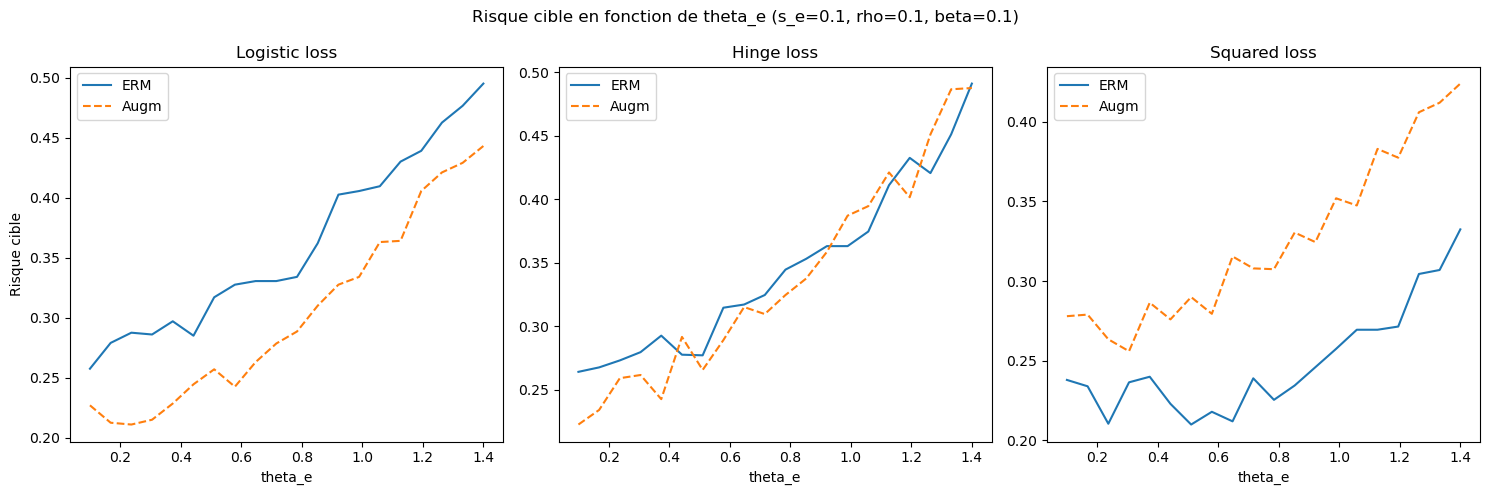

Figure sauvegardée dans risque_vs_theta_e.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(theta_e_values, risque_log_erm,       label='ERM')
axes[0].plot(theta_e_values, risque_log_augm_list,  label='Augm', linestyle='--')
axes[0].set_title('Logistic loss')
axes[0].set_xlabel('theta_e')
axes[0].set_ylabel('Risque cible')
axes[0].legend()

axes[1].plot(theta_e_values, risque_hinge_erm,       label='ERM')
axes[1].plot(theta_e_values, risque_hinge_augm_list,  label='Augm', linestyle='--')
axes[1].set_title('Hinge loss')
axes[1].set_xlabel('theta_e')
axes[1].legend()

axes[2].plot(theta_e_values, risque_squared_erm,       label='ERM')
axes[2].plot(theta_e_values, risque_squared_augm_list,  label='Augm', linestyle='--')
axes[2].set_title('Squared loss')
axes[2].set_xlabel('theta_e')
axes[2].legend()

plt.suptitle(
    f'Risque cible en fonction de theta_e '
    f'(s_e={s_e_fixed}, rho={rho}, beta={beta})'
)
plt.tight_layout()
plt.savefig('risque_vs_theta_e.png', dpi=150)
plt.show()
print("Figure sauvegardée dans risque_vs_theta_e.png")

## 13. Graphiques : risque cible en fonction de s_e

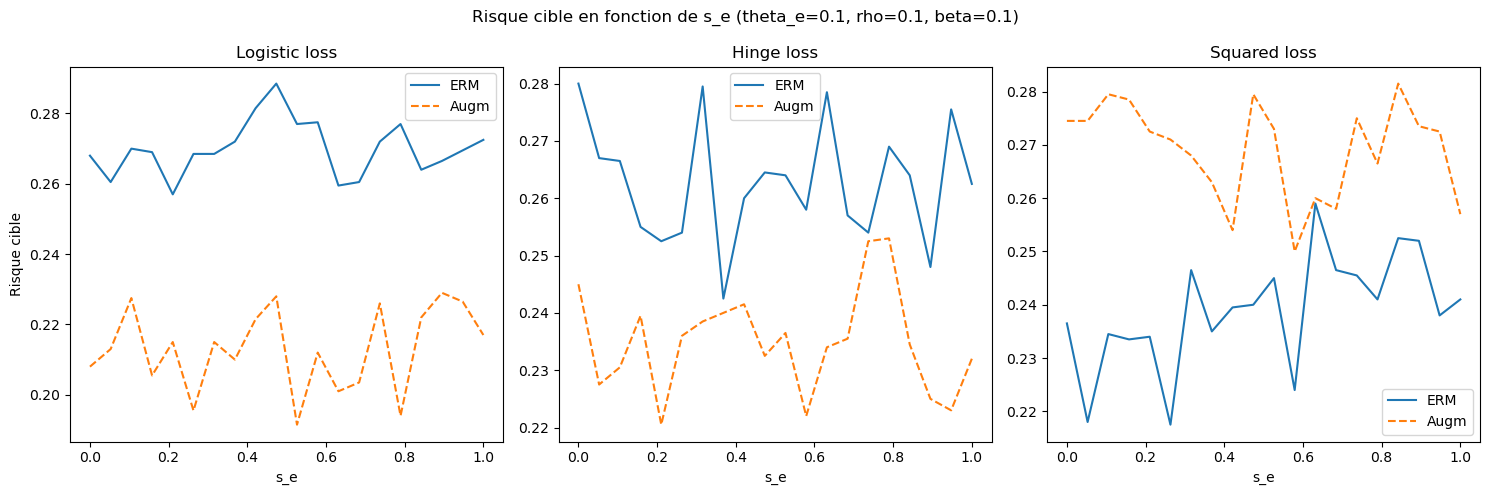

In [38]:
s_e_values = np.linspace(0.0, 1.0, 20)
theta_e_fixed = 0.1

risque_log_erm    = []
risque_hinge_erm  = []
risque_squared_erm = []
risque_log_augm_list     = []
risque_hinge_augm_list   = []
risque_squared_augm_list = []

for se in s_e_values:
    R_e = rotation(theta_e_fixed, p)
    b_e = np.zeros(p)
    b_e[1] = se
    mt = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)

    risque_log_erm.append(mt.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test))
    risque_hinge_erm.append(mt.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test))
    risque_squared_erm.append(mt.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test))

    risque_log_augm_list.append(mt.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test))
    risque_hinge_augm_list.append(mt.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test))
    risque_squared_augm_list.append(mt.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(s_e_values, risque_log_erm,      label='ERM')
axes[0].plot(s_e_values, risque_log_augm_list, label='Augm', linestyle='--')
axes[0].set_title('Logistic loss')
axes[0].set_xlabel('s_e')
axes[0].set_ylabel('Risque cible')
axes[0].legend()

axes[1].plot(s_e_values, risque_hinge_erm,      label='ERM')
axes[1].plot(s_e_values, risque_hinge_augm_list, label='Augm', linestyle='--')
axes[1].set_title('Hinge loss')
axes[1].set_xlabel('s_e')
axes[1].legend()

axes[2].plot(s_e_values, risque_squared_erm,      label='ERM')
axes[2].plot(s_e_values, risque_squared_augm_list, label='Augm', linestyle='--')
axes[2].set_title('Squared loss')
axes[2].set_xlabel('s_e')
axes[2].legend()

plt.suptitle(
    f'Risque cible en fonction de s_e '
    f'(theta_e={theta_e_fixed}, rho={rho}, beta={beta})'
)
plt.tight_layout()
plt.savefig('risque_vs_s_e.png', dpi=150)
plt.show()

## 14. Graphiques : risque cible en fonction de rho

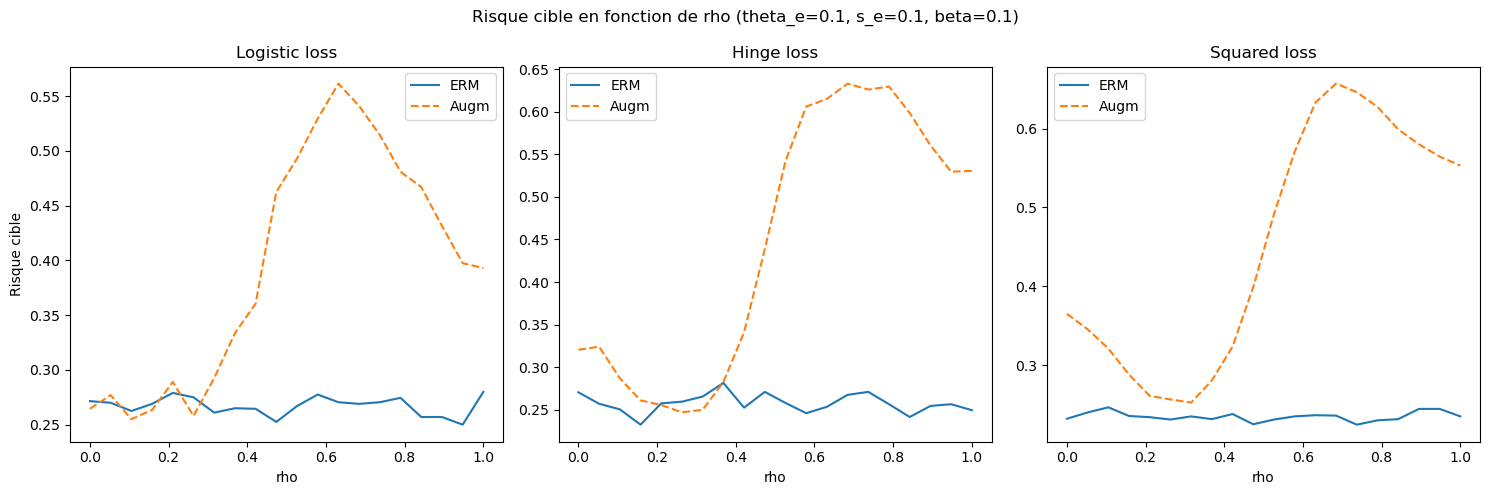

In [39]:
rho_values = np.linspace(0.0, 1.0, 20)
R_e_fixed = rotation(theta_e_fixed, p)
b_e_fixed = np.zeros(p); b_e_fixed[1] = s_e_fixed
mt_fixed = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e_fixed, biais=b_e_fixed)

risque_log_erm = []; risque_hinge_erm = []; risque_squared_erm = []
risque_log_augm_list = []; risque_hinge_augm_list = []; risque_squared_augm_list = []

for rho_val in rho_values:
    # ERM ne dépend pas de rho
    risque_log_erm.append(mt_fixed.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test))
    risque_hinge_erm.append(mt_fixed.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test))
    risque_squared_erm.append(mt_fixed.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test))
    tr = make_transform(rho_val, beta, np.random.default_rng(0))
    th1, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss1, regularizer=reg, transform=tr).sample_theta_hat(n=n_train, rng=np.random.default_rng(0), solver_maxiter=180)
    th2, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss2, regularizer=reg, transform=tr).sample_theta_hat(n=n_train, rng=np.random.default_rng(0), solver_maxiter=180)
    th3, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss3, regularizer=reg, transform=tr).sample_theta_hat(n=n_train, rng=np.random.default_rng(0), solver_maxiter=180)
    risque_log_augm_list.append(mt_fixed.error_classif_emp([th1], n_test=n_test, rng=rng_test))
    risque_hinge_augm_list.append(mt_fixed.error_classif_emp([th2], n_test=n_test, rng=rng_test))
    risque_squared_augm_list.append(mt_fixed.error_classif_emp([th3], n_test=n_test, rng=rng_test))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, erm, augm_l, title in zip(axes,
    [risque_log_erm, risque_hinge_erm, risque_squared_erm],
    [risque_log_augm_list, risque_hinge_augm_list, risque_squared_augm_list],
    ['Logistic loss', 'Hinge loss', 'Squared loss']):
    ax.plot(rho_values, erm, label='ERM')
    ax.plot(rho_values, augm_l, label='Augm', linestyle='--')
    ax.set_title(title); ax.set_xlabel('rho'); ax.legend()
axes[0].set_ylabel('Risque cible')
plt.suptitle(f'Risque cible en fonction de rho (theta_e={theta_e}, s_e={s_e}, beta={beta})')
plt.tight_layout(); plt.savefig('risque_vs_rho.png', dpi=150); plt.show()

## 15. Graphiques : risque cible en fonction de beta

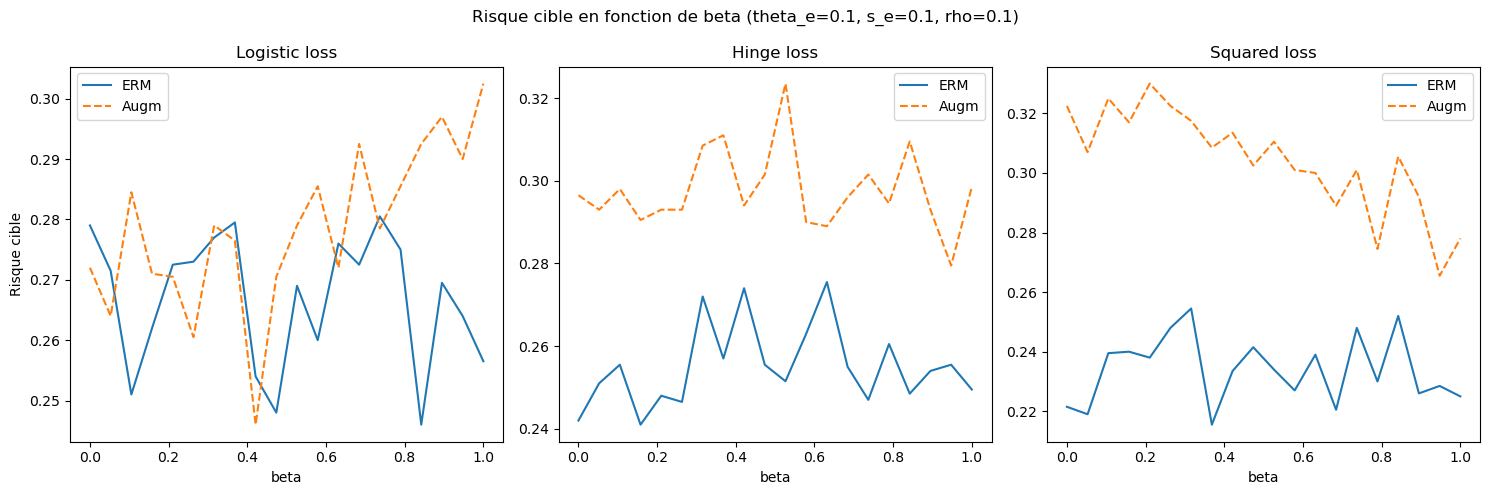

In [40]:
beta_values = np.linspace(0.0, 1.0, 20)

risque_log_erm = []; risque_hinge_erm = []; risque_squared_erm = []
risque_log_augm_list = []; risque_hinge_augm_list = []; risque_squared_augm_list = []

for beta_val in beta_values:
    risque_log_erm.append(mt_fixed.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test))
    risque_hinge_erm.append(mt_fixed.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test))
    risque_squared_erm.append(mt_fixed.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test))
    tr = make_transform(rho, beta_val, np.random.default_rng(0))
    th1, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss1, regularizer=reg, transform=tr).sample_theta_hat(n=n_train, rng=np.random.default_rng(0), solver_maxiter=180)
    th2, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss2, regularizer=reg, transform=tr).sample_theta_hat(n=n_train, rng=np.random.default_rng(0), solver_maxiter=180)
    th3, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss3, regularizer=reg, transform=tr).sample_theta_hat(n=n_train, rng=np.random.default_rng(0), solver_maxiter=180)
    risque_log_augm_list.append(mt_fixed.error_classif_emp([th1], n_test=n_test, rng=rng_test))
    risque_hinge_augm_list.append(mt_fixed.error_classif_emp([th2], n_test=n_test, rng=rng_test))
    risque_squared_augm_list.append(mt_fixed.error_classif_emp([th3], n_test=n_test, rng=rng_test))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, erm, augm_l, title in zip(axes,
    [risque_log_erm, risque_hinge_erm, risque_squared_erm],
    [risque_log_augm_list, risque_hinge_augm_list, risque_squared_augm_list],
    ['Logistic loss', 'Hinge loss', 'Squared loss']):
    ax.plot(beta_values, erm, label='ERM')
    ax.plot(beta_values, augm_l, label='Augm', linestyle='--')
    ax.set_title(title); ax.set_xlabel('beta'); ax.legend()
axes[0].set_ylabel('Risque cible')
plt.suptitle(f'Risque cible en fonction de beta (theta_e={theta_e}, s_e={s_e}, rho={rho})')
plt.tight_layout(); plt.savefig('risque_vs_beta.png', dpi=150); plt.show()

## 16. Graphiques : risque cible en fonction de lambda

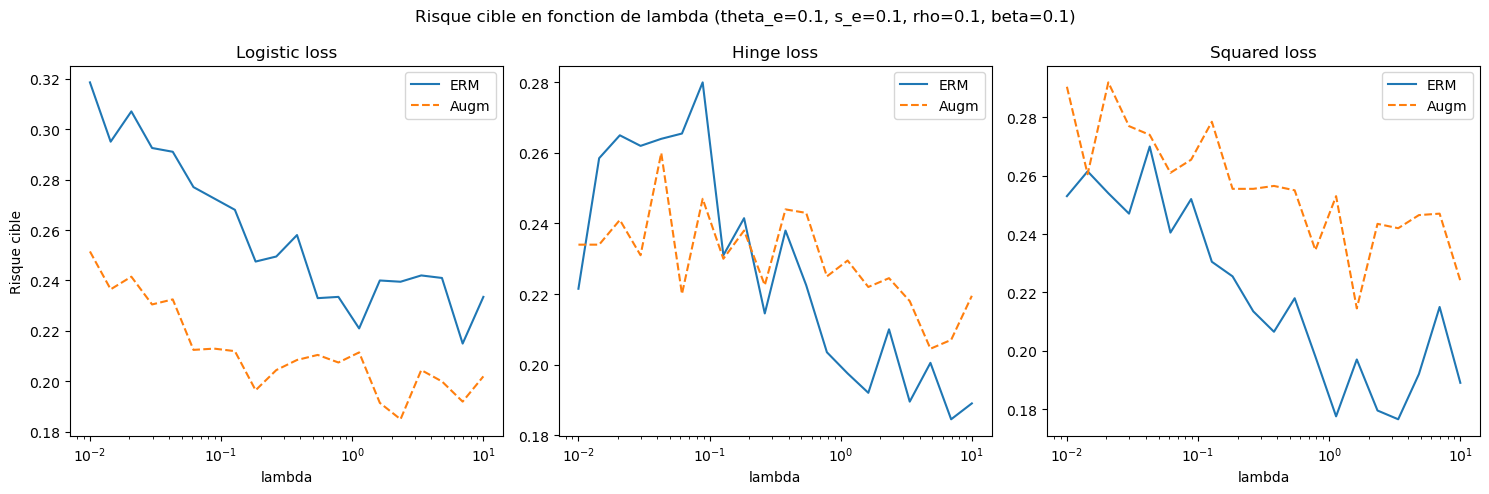

In [41]:
lam_values = np.logspace(-2, 1, 20)  # échelle log : 0.01 → 10

risque_log_erm = []; risque_hinge_erm = []; risque_squared_erm = []
risque_log_augm_list = []; risque_hinge_augm_list = []; risque_squared_augm_list = []

for lam_val in lam_values:
    reg_l = lr.QuadraticRegularizer(a=np.zeros(p), H=lam_val * np.eye(p))
    rng_l = np.random.default_rng(0)
    th1, _, _ = et.ERMTrainer(model=model_train, loss=loss1, regularizer=reg_l).sample_theta_hat(n=n_train, rng=rng_l, solver_maxiter=180)
    th2, _, _ = et.ERMTrainer(model=model_train, loss=loss2, regularizer=reg_l).sample_theta_hat(n=n_train, rng=rng_l, solver_maxiter=180)
    th3, _, _ = et.ERMTrainer(model=model_train, loss=loss3, regularizer=reg_l).sample_theta_hat(n=n_train, rng=rng_l, solver_maxiter=180)
    risque_log_erm.append(mt_fixed.error_classif_emp([th1], n_test=n_test, rng=rng_test))
    risque_hinge_erm.append(mt_fixed.error_classif_emp([th2], n_test=n_test, rng=rng_test))
    risque_squared_erm.append(mt_fixed.error_classif_emp([th3], n_test=n_test, rng=rng_test))
    tr = make_transform(rho, beta, rng_l)
    th1a, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss1, regularizer=reg_l, transform=tr).sample_theta_hat(n=n_train, rng=rng_l, solver_maxiter=180)
    th2a, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss2, regularizer=reg_l, transform=tr).sample_theta_hat(n=n_train, rng=rng_l, solver_maxiter=180)
    th3a, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss3, regularizer=reg_l, transform=tr).sample_theta_hat(n=n_train, rng=rng_l, solver_maxiter=180)
    risque_log_augm_list.append(mt_fixed.error_classif_emp([th1a], n_test=n_test, rng=rng_test))
    risque_hinge_augm_list.append(mt_fixed.error_classif_emp([th2a], n_test=n_test, rng=rng_test))
    risque_squared_augm_list.append(mt_fixed.error_classif_emp([th3a], n_test=n_test, rng=rng_test))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, erm, augm_l, title in zip(axes,
    [risque_log_erm, risque_hinge_erm, risque_squared_erm],
    [risque_log_augm_list, risque_hinge_augm_list, risque_squared_augm_list],
    ['Logistic loss', 'Hinge loss', 'Squared loss']):
    ax.semilogx(lam_values, erm, label='ERM')
    ax.semilogx(lam_values, augm_l, label='Augm', linestyle='--')
    ax.set_title(title); ax.set_xlabel('lambda'); ax.legend()
axes[0].set_ylabel('Risque cible')
plt.suptitle(f'Risque cible en fonction de lambda (theta_e={theta_e}, s_e={s_e}, rho={rho}, beta={beta})')
plt.tight_layout(); plt.savefig('risque_vs_lambda.png', dpi=150); plt.show()

## 17. Graphiques : risque cible en fonction de n

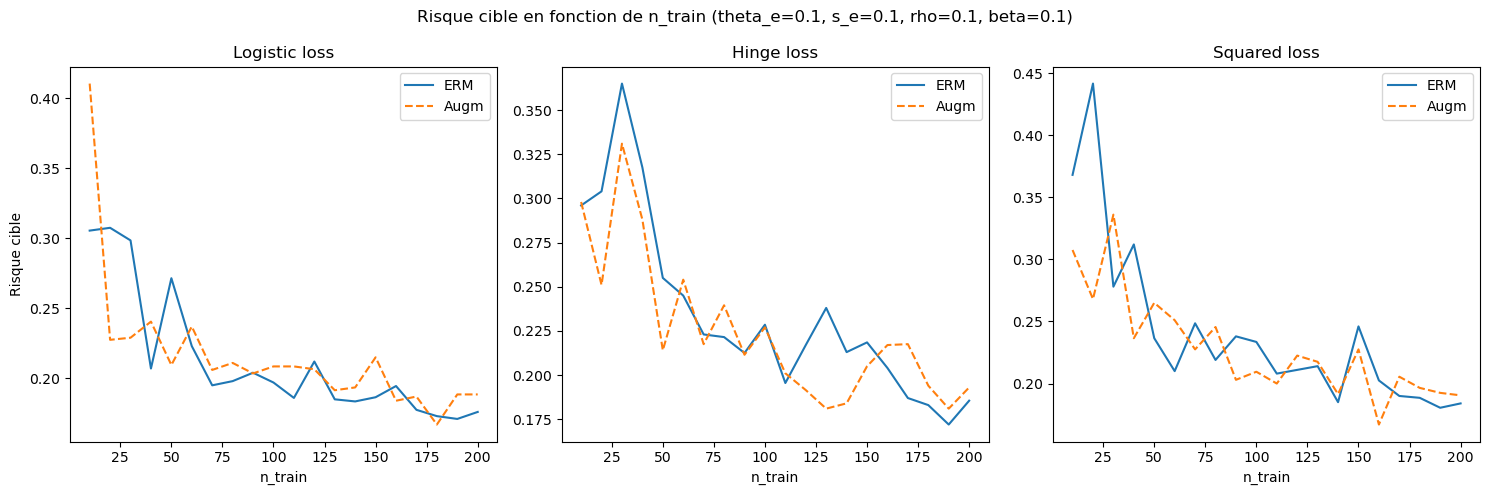

In [42]:
n_train_values = np.arange(10, 210, 10)

risque_log_erm = []; risque_hinge_erm = []; risque_squared_erm = []
risque_log_augm_list = []; risque_hinge_augm_list = []; risque_squared_augm_list = []

for n_val in n_train_values:
    rng_n = np.random.default_rng(0)
    th1, _, _ = et.ERMTrainer(model=model_train, loss=loss1, regularizer=reg).sample_theta_hat(n=n_val, rng=rng_n, solver_maxiter=180)
    th2, _, _ = et.ERMTrainer(model=model_train, loss=loss2, regularizer=reg).sample_theta_hat(n=n_val, rng=rng_n, solver_maxiter=180)
    th3, _, _ = et.ERMTrainer(model=model_train, loss=loss3, regularizer=reg).sample_theta_hat(n=n_val, rng=rng_n, solver_maxiter=180)
    risque_log_erm.append(mt_fixed.error_classif_emp([th1], n_test=n_test, rng=rng_test))
    risque_hinge_erm.append(mt_fixed.error_classif_emp([th2], n_test=n_test, rng=rng_test))
    risque_squared_erm.append(mt_fixed.error_classif_emp([th3], n_test=n_test, rng=rng_test))
    tr = make_transform(rho, beta, rng_n)
    th1a, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss1, regularizer=reg, transform=tr).sample_theta_hat(n=n_val, rng=rng_n, solver_maxiter=180)
    th2a, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss2, regularizer=reg, transform=tr).sample_theta_hat(n=n_val, rng=rng_n, solver_maxiter=180)
    th3a, _, _ = augm.DataAugmTrainer(model=model_train, loss=loss3, regularizer=reg, transform=tr).sample_theta_hat(n=n_val, rng=rng_n, solver_maxiter=180)
    risque_log_augm_list.append(mt_fixed.error_classif_emp([th1a], n_test=n_test, rng=rng_test))
    risque_hinge_augm_list.append(mt_fixed.error_classif_emp([th2a], n_test=n_test, rng=rng_test))
    risque_squared_augm_list.append(mt_fixed.error_classif_emp([th3a], n_test=n_test, rng=rng_test))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, erm, augm_l, title in zip(axes,
    [risque_log_erm, risque_hinge_erm, risque_squared_erm],
    [risque_log_augm_list, risque_hinge_augm_list, risque_squared_augm_list],
    ['Logistic loss', 'Hinge loss', 'Squared loss']):
    ax.plot(n_train_values, erm, label='ERM')
    ax.plot(n_train_values, augm_l, label='Augm', linestyle='--')
    ax.set_title(title); ax.set_xlabel('n_train'); ax.legend()
axes[0].set_ylabel('Risque cible')
plt.suptitle(f'Risque cible en fonction de n_train (theta_e={theta_e}, s_e={s_e}, rho={rho}, beta={beta})')
plt.tight_layout(); plt.savefig('risque_vs_n_train.png', dpi=150); plt.show()